*   훈련 셋과 테스트 셋을 나누는 방법 (추출=sampling)
    *   순차 추출(sequentian sampling)
    *   임의 추출(random sampling)
    *   층화 추출(stratified sampling)
*   분류 모델의 평가 지표(metrics)
    *   정확도(accuracy)
    *   정밀도(precision)
    *   재현율(racall)
    *   F1 score
*   특성 스케일링(feature scaling)
    *   표준화(standardization)
    *   정규화(normalization)        

# 모듈 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 사이키런 특징 카멜표기 class, 함수메서드 스네이크표기
from sklearn.neighbors import KNeighborsClassifier # 머신러닝 모델
from sklearn.model_selection import train_test_split # 훈련/테스트 셋 분리 함수
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # 정확도 정밀도 재현율 f1 = 평가지표 계산함수
from sklearn.metrics import classification_report, confusion_matrix # 평가 지표 내용 출력
from sklearn.preprocessing import StandardScaler, MinMaxScaler # 특성(전처리) 스케일링 변환기

# 데이터 준비

In [2]:
file_path ='https://bit.ly/fish_csv_data'

In [3]:
fish=pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
fish.tail()

,Species,Weight,Length,Diagonal,Height,Width
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,15.0,16.2,2.9322,1.8792


In [6]:
pd.set_option('display.max_rows',10)

In [7]:
fish

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [8]:
df=fish[fish.Species.isin(['Bream','Smelt'])] #Bream, Smelt 선택
# df=fish[fish.Species.isin(['Bream','Smelt'])]

In [9]:
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [10]:
x = df[['Weight','Length']].values # 특성 배열
# x=df[['Weight','Length']].values

In [11]:
x[:5]

array([[242. ,  25.4],
       [290. ,  26.3],
       [340. ,  26.5],
       [363. ,  29. ],
       [430. ,  29. ]])

In [12]:
x[-5:]

array([[12.2, 12.2],
       [13.4, 12.4],
       [12.2, 13. ],
       [19.7, 14.3],
       [19.9, 15. ]])

In [13]:
y=df.Species.values # 타겟 배열
# y=df.Species.values

In [14]:
y

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

# 훈련 셋/테스트 셋 분리

* 머신 러닝(Machine Learning): 컴퓨터가 데이터를 학습해서 예측.
* 훈련(train)/학습(learning): 머신 러닝 알고리즘(모델)에게 특성 데이터(와 레이블)을 제공.
* 평가: 학습된 데이터와 학습되지 않은 데이터를 얼마나 잘 예측하는지 점수화.
* 훈련 셋: 머신러닝 모델에게 제공할 특성 데이터(과 레이블)
* 테스트 셋: 학습되지 않은 데이터를 얼마나 잘 예측하는지 평가하기 위해서 남겨두는 데이터(와 레이블)


## 순차 추출(sequential sampling)

(몇개 자름)

In [15]:
num_trains=35 # 훈련 셋 샘플 개수(전체 샘플의 약 70%)

In [16]:
x_train =x[:num_trains] # 훈련 셋
x_test =x[num_trains:] # 테스트 셋

In [100]:
x_train

array([[ 720. ,   35. ],
       [   6.7,    9.8],
       [ 680. ,   35. ],
       [  13.4,   12.4],
       [   8.7,   11.3],
       [ 242. ,   25.4],
       [ 600. ,   32. ],
       [ 500. ,   30.7],
       [ 290. ,   26.3],
       [ 700. ,   33. ],
       [ 920. ,   38.5],
       [1000. ,   37. ],
       [ 714. ,   36. ],
       [   9.8,   11.2],
       [ 363. ,   29. ],
       [   7.5,   10.5],
       [   9.7,   11. ],
       [ 450. ,   29.7],
       [  19.7,   14.3],
       [ 700. ,   35. ],
       [   9.8,   12. ],
       [ 500. ,   31.5],
       [ 975. ,   41. ],
       [ 650. ,   33.5],
       [ 700. ,   33. ],
       [ 340. ,   26.5],
       [ 340. ,   32. ],
       [ 925. ,   39.5],
       [   9.9,   11.8],
       [ 450. ,   30. ],
       [  12.2,   12.2],
       [ 500. ,   31. ],
       [ 430. ,   29. ],
       [ 955. ,   38.5],
       [ 685. ,   34. ]])

In [18]:
x_test

array([[ 6.7,  9.8],
       [ 7.5, 10.5],
       [ 7. , 10.6],
       [ 9.7, 11. ],
       [ 9.8, 11.2],
       [ 8.7, 11.3],
       [10. , 11.8],
       [ 9.9, 11.8],
       [ 9.8, 12. ],
       [12.2, 12.2],
       [13.4, 12.4],
       [12.2, 13. ],
       [19.7, 14.3],
       [19.9, 15. ]])

In [19]:
y_train=y[:num_trains] # 훈련 레이블
y_test=y[num_trains:] # 테스트 레이블

In [20]:
y_train # 정렬되어있으면 순차추출이 별로안좋다

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [21]:
y_test

array(['Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

In [22]:
x_train.shape

(35, 2)

In [23]:
x_test.shape

(14, 2)

In [24]:
y_train.shape

(35,)

In [25]:
y_test.shape

(14,)

In [26]:
# KNN 모델 생성
knn = KNeighborsClassifier(n_neighbors=5)

In [27]:
knn.fit(X=x_train,y=y_train)#X 대문자 2차원이상 배열 x 소문자 1차원 배열 //  Bream을공부했는데

KNeighborsClassifier()

In [28]:
# 훈련된 KNN 모델을 훈련 셋으로 평가 - 훈련 셋에서의 정확도
knn.score(X=x_train,y=y_train)

1.0

In [29]:
# KNN 모델을 훈련할 때 사용하지 않았던 테스트 셋으로 평가 - 테스트 셋에서의 정확도 // Smelt를 넣으면?
knn.score(X=x_test,y=y_test)

0.0

In [30]:
knn.predict(X=x_test)

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [31]:
y_test

array(['Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

샘플들이 어떤 기준으로 정렬되어 있는 경우에는 순차 추출을 하게 되면 한번도 훈련되지 않는 레이블들이 있을 수 있기 때문에, 순차 추출을 사용하면 안됨.

## 임의 추출(random sampling)

In [32]:
# 전체 샘플 49 개를 indices에저장
indices = np.arange(0,49)
print(indices)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


In [33]:
np.random.seed(42)
np.random.shuffle(indices) # 배열의 원소들을 무작위로 섞어줌. indices를 섞어

In [34]:
print(indices)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [35]:
# num_trains는 35 ,총 indices의섞여있는49개중 [:35만큼]train_indices에 넣어
train_indices=indices[:num_trains] # 훈련 셋을 샘플링하기 위한 인덱스들
test_indices=indices[num_trains:] # 테스트 셋을 샘플링하기 위한 인덱스들

In [36]:
print(train_indices)
print(test_indices)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2]
[37 35 23 39 10 22 18 48 20  7 42 14 28 38]


array([[ 242. ,   25.4],
       [ 290. ,   26.3],
       [ 340. ,   26.5],
       [ 363. ,   29. ],
       [ 430. ,   29. ],
       [ 450. ,   29.7],
       [ 500. ,   29.7],
       [ 390. ,   30. ],
       [ 450. ,   30. ],
       [ 500. ,   30.7],
       [ 475. ,   31. ],
       [ 500. ,   31. ],
       [ 500. ,   31.5],
       [ 340. ,   32. ],
       [ 600. ,   32. ],
       [ 600. ,   32. ],
       [ 700. ,   33. ],
       [ 700. ,   33. ],
       [ 610. ,   33.5],
       [ 650. ,   33.5],
       [ 575. ,   34. ],
       [ 685. ,   34. ],
       [ 620. ,   34.5],
       [ 680. ,   35. ],
       [ 700. ,   35. ],
       [ 725. ,   35. ],
       [ 720. ,   35. ],
       [ 714. ,   36. ],
       [ 850. ,   36. ],
       [1000. ,   37. ],
       [ 920. ,   38.5],
       [ 955. ,   38.5],
       [ 925. ,   39.5],
       [ 975. ,   41. ],
       [ 950. ,   41. ],
       [   6.7,    9.8],
       [   7.5,   10.5],
       [   7. ,   10.6],
       [   9.7,   11. ],
       [   9.8,   11.2],


In [37]:
#x는 무게와 길이 2차원인 배열 섞여있는 35개와 14개
x_train= x[train_indices] # 훈련 셋
x_test= x[test_indices] # 테스트 셋

In [38]:
x_train.shape

(35, 2)

In [39]:
x_test.shape

(14, 2)

In [40]:
x_train[:6]

array([[340. ,  32. ],
       [ 13.4,  12.4],
       [ 19.7,  14.3],
       [ 12.2,  12.2],
       [700. ,  33. ],
       [714. ,  36. ]])

In [41]:
y_train=y[train_indices] # 훈련 레이블
y_test=y[test_indices] # 테스트 레이블

In [42]:
y_train[:6]

array(['Bream', 'Smelt', 'Smelt', 'Smelt', 'Bream', 'Bream'], dtype=object)

In [43]:
# KNN 모델 생성
knn =KNeighborsClassifier(n_neighbors=5)


In [44]:
# 모델 훈련
knn.fit(X=x_train,y=y_train)

KNeighborsClassifier()

In [45]:
# 훈련 셋 평가 - 정확도
knn.score(X=x_train,y=y_train)

1.0

In [46]:
# 테스트 셋 평가 - 정확도
knn.score(X=x_test,y=y_test)

1.0

In [47]:
# 훈련 레이블에서 도미/빙어 빈도수 비율
pd.Series(y_train).value_counts(normalize=True) #normalize=True 비율

,proportion
Bream,0.771429
Smelt,0.228571


In [48]:
# 테스트 레이블에서 도미/빙어 비율
pd.Series(y_test).value_counts(normalize=True)

,proportion
Bream,0.571429
Smelt,0.428571


임의 추출(random sampling)의 단점은 훈련 셋과 테스트 셋에서 각 클래스(도미/빙어)들의 비율이 비슷하지 않을 수도 있음. 머신 러닝 모델의 성능이 안 좋아질 수 있음. 이런 단점을 보완하는 추출 방식이 층화 추출.

## 층화 추출(stratified sampling)

In [49]:
x_train,x_test,y_train,y_test =train_test_split(x,y,train_size=35,random_state=42,
                                                stratify=y)#가변길이 // traindata= 전체 데이터중 몇개 // stratify=y는 고정

In [50]:
x_train

array([[ 720. ,   35. ],
       [   6.7,    9.8],
       [ 680. ,   35. ],
       [  13.4,   12.4],
       [   8.7,   11.3],
       [ 242. ,   25.4],
       [ 600. ,   32. ],
       [ 500. ,   30.7],
       [ 290. ,   26.3],
       [ 700. ,   33. ],
       [ 920. ,   38.5],
       [1000. ,   37. ],
       [ 714. ,   36. ],
       [   9.8,   11.2],
       [ 363. ,   29. ],
       [   7.5,   10.5],
       [   9.7,   11. ],
       [ 450. ,   29.7],
       [  19.7,   14.3],
       [ 700. ,   35. ],
       [   9.8,   12. ],
       [ 500. ,   31.5],
       [ 975. ,   41. ],
       [ 650. ,   33.5],
       [ 700. ,   33. ],
       [ 340. ,   26.5],
       [ 340. ,   32. ],
       [ 925. ,   39.5],
       [   9.9,   11.8],
       [ 450. ,   30. ],
       [  12.2,   12.2],
       [ 500. ,   31. ],
       [ 430. ,   29. ],
       [ 955. ,   38.5],
       [ 685. ,   34. ]])

In [51]:
x_test

array([[610. ,  33.5],
       [475. ,  31. ],
       [575. ,  34. ],
       [  7. ,  10.6],
       [ 10. ,  11.8],
       [620. ,  34.5],
       [850. ,  36. ],
       [500. ,  29.7],
       [ 12.2,  13. ],
       [600. ,  32. ],
       [950. ,  41. ],
       [390. ,  30. ],
       [725. ,  35. ],
       [ 19.9,  15. ]])

In [52]:
y_train

array(['Bream', 'Smelt', 'Bream', 'Smelt', 'Smelt', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt',
       'Bream', 'Smelt', 'Smelt', 'Bream', 'Smelt', 'Bream', 'Smelt',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [53]:
y_test

array(['Bream', 'Bream', 'Bream', 'Smelt', 'Smelt', 'Bream', 'Bream',
       'Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt'],
      dtype=object)

`train_test_split()` 함수 파라미터:

*   가변길이 인수(*arrays): 훈련 셋과 테스트 셋으로 나눌 배열(들).
*   `test_size`: 테스트 셋의 샘플 개수(0 이상의 정수) 또는 비율(0.0~1.0)
    * test_size를 설정하면 train_size는 자동으로 결정.
*   `train_size`: 훈련 셋의 샘플 개수 또는 비율.
    * train_size를 설정하면 test_size는 자동으로 결정.
*   `ramdom_state`: 난수를 생성할 때 사용할 seed 값.
*   `shuffle`: 샘플들을 무작위로 섞을 지 여부를 설정. 기본값은 True. random sampling이 기본 동작. **기본값 False는 순차추출**     
*   `stratify`: 층화 추출(stratified sampling)을 하기 위해서 각 클래스들의 비율을 알 수 있는 1차원 배열. 기본값은 None.


In [54]:
# 훈련 레이블의 각 클래스 비율
pd.Series(y_train).value_counts(normalize=True)

,proportion
Bream,0.714286
Smelt,0.285714


In [55]:
# 테스트 레이블에서의 각 클래스 비율
pd.Series(y_test).value_counts(normalize=True)

,proportion
Bream,0.714286
Smelt,0.285714


In [56]:
# train_test_split
# >>> X, y = np.arange(10).reshape((5, 2)), range(5)
# # >>> X
# # array([[0, 1],
# #        [2, 3],
# #        [4, 5],
# #        [6, 7],
# #        [8, 9]])
# # >>> list(y)
# # [0, 1, 2, 3, 4]
# >>> X_train, X_test, y_train, y_test = train_test_split(
# ...     X, y, test_size=0.33, random_state=42)
# ...
# # >>> X_train
# # array([[4, 5],
# #        [0, 1],
# #        [6, 7]])
# # >>> y_train
# # [2, 0, 3]
# # >>> X_test
# # array([[2, 3],
# #        [8, 9]])
# # >>> y_test
# # [1, 4]
# # >>> train_test_split(y, shuffle=False)
# # [[0, 1, 2], [3, 4]]

In [57]:
# # 훈련 셋과 테스트 셋 시각화
# # 훈련 셋(x_train) 산점도
# # 테스트 셋(x_test) 산점도

# sns.scatterplot(data=x_train)
# sns.scatterplot(data=x_test)
# plt.show()

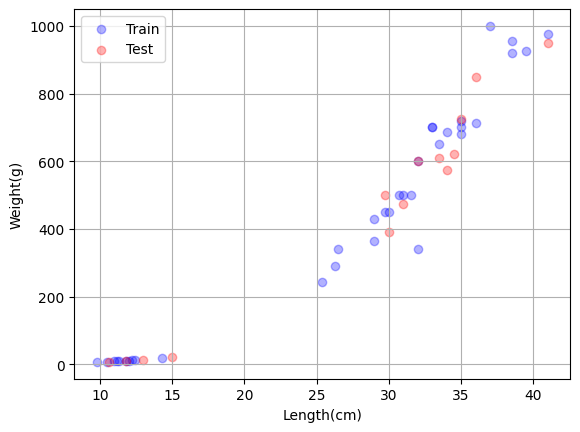

In [58]:
# # 훈련 셋과 테스트 셋 시각화
# # 훈련 셋(x_train) 산점도

plt.scatter(x_train[:,1],x_train[:,0],alpha=0.3,label='Train',color='blue')
# # 테스트 셋(x_test) 산점도
# plt.scatter(x_train[:,1],x_train[:,0])
plt.scatter(x_test[:,1],x_test[:,0],alpha=0.3,label='Test',color='red')
plt.legend()
plt.grid()
plt.xlabel('Length(cm)')
plt.ylabel('Weight(g)')
plt.show()

In [59]:
# KNN 모델 생성
knn= KNeighborsClassifier(n_neighbors=5)



In [60]:
# KNN 모델 훈련
knn.fit(X=x_train,y=y_train)

KNeighborsClassifier()

In [61]:
# 훈련 셋 평가
knn.score(X=x_train,y=y_train)

1.0

In [62]:
# 테스트 셋 평가
knn.score(X=x_test,y=y_test)

1.0

# 분류 평가 지표

| 구분 | 예측 양성(Predicted Positive) | 예측 음성(Predicted Negative) |
| :--- | :--- | :--- |
| **실제 양성(Actual Positive)** | TP(True Positive) | FN(False Negative) |
| **실제 음성(Actual Negative)** | FP(False Positive) | TN(True Negative) |

* 용어 정의
  * TP(True Positive): 진양성. 실제 양성인 샘플을 양성으로 맞게 예측한 것.(정답을 맞춤)
  * FN(False Negative): 가음성. 실제 양성인 샘플을 음성으로 틀리게 예측한 것.(오답)
  * FP(False Positive): 가양성. 실제 음성인 샘플을 양성으로 틀리게 예측한 것.(오답)
  * TN(True Negative): 진음성. 실제 음성인 샘플을 음성으로 맞게 예측한 것.(정답을 맞춤)
* **정확도(accuracy)**: 샘플들을 정확하게 분류한 비율. 전체 샘플에서 정답에 비율.
> accuacy = $$(TP + TN) / (TP + FN + FP + TN)$$
* **정밀도(precision)**: 양성 예측들 중에서 정답의 비율. P
> precision = $$TP / (TP + FP)$$
* **재현율(recall)**: 실제 양성 샘플 중에서 정답의 비율. R
> recall = $$TP / (TP + FN)$$
* **F1 score**: 정밀도와 재현율의 조화 평균(역수들의 평균의 역수)
> F1-score = $$2 / (1/precision + 1/recall)$$,$$1 / (1/precision + 1/recall) / 2$$

In [63]:
# 정밀도 스팸메일
# 재현율
# 테스트 셋 예측값
test_predict = knn.predict(X=x_test)
print(test_predict)

['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Bream' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt']


In [64]:
print(y_test)
print(test_predict)

['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Bream' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt']
['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Bream' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt']


In [65]:
# 테스트 셋 혼동 행렬(confusion matrix): TP/FN/FP/TN 개수를 보여주는 행렬
confusion_matrix(y_true=y_test,y_pred=test_predict) # 도미10 도미빙어0
                                                    # 빙어도미0 빙어4

array([[10,  0],
       [ 0,  4]])

In [66]:
report=classification_report(y_true=y_test,y_pred=test_predict)
print(report)
# report.frame

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        10
       Smelt       1.00      1.00      1.00         4

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



In [67]:
accuracy_score(y_true=y_test,y_pred=test_predict)

1.0

In [68]:
# Bream을 양성(positive)로 간주할 때의 정밀도
precision_score(y_true=y_test,y_pred=test_predict,pos_label='Bream')#브림 0 스멜트 1

1.0

In [69]:
# Bream을 양성으로 간주할 때의 재현율
recall_score(y_true=y_test,y_pred=test_predict,pos_label='Bream')

1.0

In [70]:
# Bream을 양성으로 간주할 때의 f1-score
f1_score(y_true=y_test,y_pred=test_predict,pos_label='Bream')

1.0

# 특성 스케일링(feature scaling)

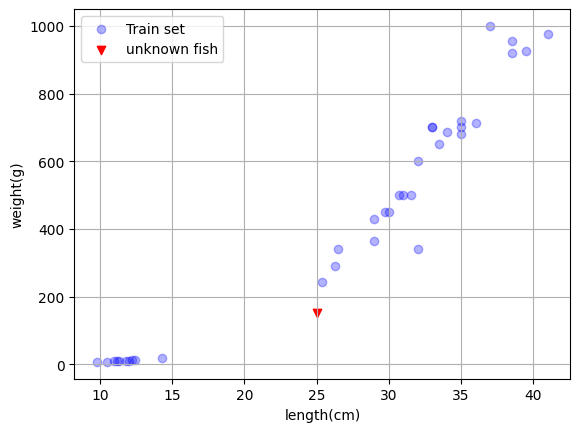

In [71]:
# 훈련 셋(x_train) 시각화
plt.scatter(x=x_train[:,1],y=x_train[:,0],alpha=0.3, color='blue', label='Train set')

# 가상의 물고기(150, 25) 데이터

unknown=np.array([[150,25]]) # 특성 배열은 반드시 2d array이어야 하기 때문이다.
plt.scatter(unknown[:,1],unknown[:,0],color='red',marker='v',label='unknown fish')
# plt.scatter(25,150,color='red',marker='v',label='unknown fish') 숫자써도가능

plt.legend()

plt.grid()
plt.xlabel('length(cm)')
plt.ylabel('weight(g)')
plt.show()

In [72]:
# 가상의 물고기(150, 25)의 예측값
prediction=knn.predict(unknown)
print(prediction)

['Smelt']


In [73]:
# 훈련된 KNN 모델이 찾은(빨간점에서) 5개의 가장 가까운 이웃들(거리, 인덱스)
distances, indices = knn.kneighbors(X=unknown,n_neighbors=5)
print(distances)
print(indices)

[[ 92.00086956 130.73859415 137.17988191 138.39320793 140.00603558]]
[[ 5 18  3 30  8]]


In [101]:
# indices

array([[ 5,  8, 25, 14, 26]])

In [74]:
# 가장 가까운 이웃(훈련 셋)
x_train[indices[0]]

array([[242. ,  25.4],
       [ 19.7,  14.3],
       [ 13.4,  12.4],
       [ 12.2,  12.2],
       [290. ,  26.3]])

In [75]:
# 가장 가까운 이웃들의 레이블
y_train[indices[0]] # 다수결로 unknown은 빙어가되었다

array(['Bream', 'Smelt', 'Smelt', 'Smelt', 'Bream'], dtype=object)

*   물고기의 두 특성(무게, 길이)은 단위(g , cm)가 다르기 때문에, 값의 범위도 매우 다르다.
    * 무게 범위:0~1,000g
    * 길이 범위:0~50cm
    * 특성(변수)들의 스케일이 매우 다름.
    * 가장 가까운 이웃들을 찾기 위해서 거리를 계산할 때, 물고기의 길이가 거리에 미치는 영향은 물고기의 무게가 거리에 미치는 영향에 비해서 매우 미비.
    * 예측을 할 때 거리 계산에 영향이 적은 변수(특성)은 무시되기 쉬움.
    * KNN과 같은 거리를 기반으로 하는 머신 러닝 모델을 사용할 때는, 모든 변수(특성)들이 거리 계산에 비슷한 영향을 줄 수 있도록 스케일을 변환할 필요가 있다.
*   특성 스케일링 전처리(pre-processing)
    * **표준화(standardization)**: **훈련 셋**의 평균과 표준편차를 사용해서 훈련 셋과 테스트 셋의 특성 값들을 변환하는 것.
    * **정규화(normalization)**: min-max scaling. **훈련 셋**의 최솟값과 최댓값을 사용해서 훈련 셋과 테스트 셋의 특성 값들을 변환하는 것.

## 표준화(standardization)

In [76]:
std_scaler = StandardScaler() # 표준화 수행 변환기 객체 생성

In [77]:
# 표준화하기 위해서 필요한 평균, 표준편차를 훈련 셋에서 계산. 훈련셋으로피팅 아래두개가피팅의결과
std_scaler.fit(X=x_train)

StandardScaler()

In [78]:
std_scaler.mean_ # [무게의 평균, 길이의 평균] axis=0을 따라서

array([441.04      ,  26.81714286])

In [79]:
std_scaler.var_ # [무게의 분산, 길이의 분산] axis=0을 따라서

array([1.09021047e+05, 1.04260278e+02])

In [80]:
# 훈련 셋 스케일 변환
x_tr_scaled = std_scaler.transform(X=x_train)
print(x_tr_scaled[:6])

[[ 0.84486391  0.80139297]
 [-1.31545093 -1.66658399]
 [ 0.7237191   0.80139297]
 [-1.29515918 -1.41195145]
 [-1.30939369 -1.5196806 ]
 [-0.60281658 -0.13878873]]


In [81]:
x_tr_scaled.mean(axis=0) # 훈련 셋에서 무게, 길이의 평균

array([6.66133815e-17, 2.22044605e-16])

In [82]:
x_tr_scaled.std(axis=0) # 훈련 셋에서 무게, 길이의 표준편차

array([1., 1.])

In [83]:
# KNN 분류 모델을 생성
knn=KNeighborsClassifier(n_neighbors=5)

In [84]:
# KNN 모델을 스케일 변환된 훈련 셋으로 훈련.
knn.fit(X=x_tr_scaled, y=y_train)

KNeighborsClassifier()

In [ ]:
# asd=std_scaler.fit_transform(X=x_test)

In [85]:
# 훈련된 KNN 모델의 (스케일링된) 훈련 셋 정확도
knn.score(X=x_tr_scaled, y=y_train)

1.0

In [86]:
# 테스트 셋을 (훈련 셋의 평균과 표준편차를 사용해서) 표준화 수행.
x_te_scaled =std_scaler.transform(X=x_test)
print(x_te_scaled)

[[ 0.51171568  0.65448958]
 [ 0.10285194  0.4096506 ]
 [ 0.40571397  0.70345738]
 [-1.31454235 -1.58823552]
 [-1.30545648 -1.47071281]
 [ 0.54200188  0.75242518]
 [ 1.23858455  0.89932857]
 [ 0.17856745  0.28233433]
 [-1.29879352 -1.35319009]
 [ 0.48142948  0.50758619]
 [ 1.54144658  1.38900654]
 [-0.15458078  0.311715  ]
 [ 0.86000701  0.80139297]
 [-1.27547314 -1.1573189 ]]


In [87]:
# 스케일링된 테스트 셋에서의 정확도
knn.score(X=x_te_scaled,y=y_test)

1.0

In [88]:
x_te_scaled[:6]

array([[ 0.51171568,  0.65448958],
       [ 0.10285194,  0.4096506 ],
       [ 0.40571397,  0.70345738],
       [-1.31454235, -1.58823552],
       [-1.30545648, -1.47071281],
       [ 0.54200188,  0.75242518]])

150, 25 가상의 물고기의 예측값을 계산

In [89]:
unknowns_scaled=std_scaler.transform(unknown)

In [90]:
print(unknowns_scaled)

[[-0.88144965 -0.17796297]]


In [91]:
distances,indices = knn.kneighbors(X=unknowns_scaled)

In [92]:
print(distances)
print(indices)

[[0.28137343 0.44270897 0.59389336 0.75472584 0.89504546]]
[[ 5  8 25 14 26]]


In [93]:
x_train[indices[0]]

array([[242. ,  25.4],
       [290. ,  26.3],
       [340. ,  26.5],
       [363. ,  29. ],
       [340. ,  32. ]])

In [94]:
y_train[indices[0]]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

In [95]:
knn.predict(X=unknowns_scaled)

array(['Bream'], dtype=object)

In [96]:
# min-max 계산하기

In [102]:
print(np.min(x_tr_scaled))
print(np.max(x_te_scaled))

-1.6665839934404698
1.5414465765906908
